In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

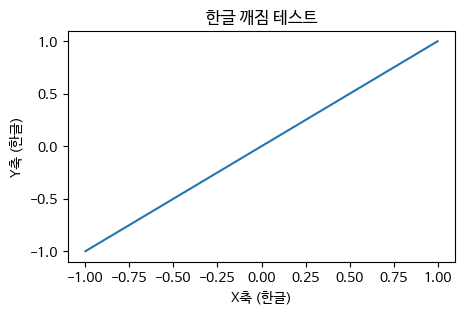

In [2]:
# 1. 폰트 설치 및 캐시 업데이트 (실행 후 '런타임 재시작' 필요)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 2. 폰트 설정 및 라이브러리 임포트
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

# 한글 폰트 경로 설정 (나눔바른고딕)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("설치가 완료되었습니다. [런타임] -> [세션 다시 시작] 을 클릭한 뒤, 이 셀을 한 번 더 실행해주세요!")
4
# --- 확인용 테스트 그래프 ---
plt.figure(figsize=(5,3))
plt.title("한글 깨짐 테스트")
plt.plot([-1, 0, 1], [-1, 0, 1])
plt.xlabel("X축 (한글)")
plt.ylabel("Y축 (한글)")
plt.show()

In [3]:
import pandas as pd
import numpy as np

file_path = '/content/drive/MyDrive/CV/processed_HN07~24.csv'
new_df = pd.read_csv(file_path, low_memory=False)

In [4]:
import pandas as pd

# HE_HbA1c 컬럼의 결측치 개수 확인
missing_count = new_df['HE_HbA1c'].isna().sum()
print(f"HE_HbA1c 결측치 개수: {missing_count}")

HE_HbA1c 결측치 개수: 30380


In [5]:
# 1. 제거 전 행 개수 저장
before_count = len(new_df)

# 2. HE_HbA1c 또는 wt_tot 컬럼에 결측치가 있는 행 제거
new_df = new_df.dropna(subset=['HE_HbA1c', 'wt_tot'])

# 3. 제거 후 행 개수 저장
after_count = len(new_df)
deleted_count = before_count - after_count

# 4. 삭제 비율 계산
# 0으로 나누는 에러를 방지하기 위해 조건문을 넣거나 간단히 계산합니다.
deleted_percent = (deleted_count / before_count) * 100

# 5. 결과 출력
print(f"제거 전 데이터 개수: {before_count:,}개")
print(f"제거 후 데이터 개수: {after_count:,}개")
print("-" * 30)
print(f"삭제된 결측치 개수: {deleted_count:,}개")
print(f"삭제된 비율: {deleted_percent:.2f}%")

제거 전 데이터 개수: 111,368개
제거 후 데이터 개수: 71,871개
------------------------------
삭제된 결측치 개수: 39,497개
삭제된 비율: 35.47%


위험군 진단 비율(가중치 고려)

In [11]:
# year 2023-2024 및 HE_HbA1c 5.7~7.9 또는 HE_glu >= 100 필터링
filtered_df = new_df[
    (new_df['year'].isin([2023, 2024])) &
    (
        ((new_df['HE_HbA1c'] >= 5.7) & (new_df['HE_HbA1c'] < 6.5))
    )
]

# wt_tot 가중치 적용 비율
total_weight = filtered_df['wt_tot'].sum()
de1_weight = filtered_df.loc[filtered_df['DE1_dg'] == '1.0', 'wt_tot'].sum()

ratio_weighted = de1_weight / total_weight * 100

print(f"전체 가중 count: {total_weight:,.2f}")
print(f"DE1_dg == '1.0' 가중 count: {de1_weight:,.2f}")
print(f"DE1_dg == '1.0' 가중 비율: {ratio_weighted:.2f}%")

전체 가중 count: 18,677,342.80
DE1_dg == '1.0' 가중 count: 3,203,624.85
DE1_dg == '1.0' 가중 비율: 17.15%


CDF

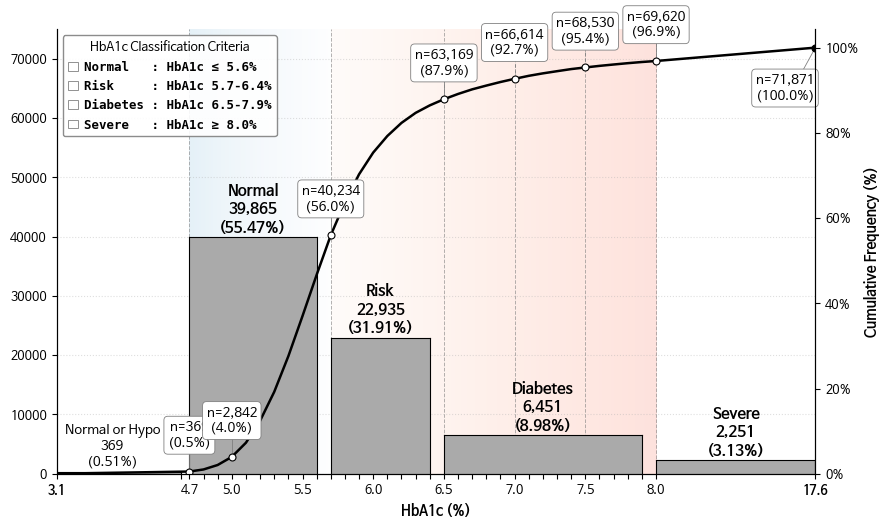

In [8]:
plt.close('all')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import pandas as pd

# ── 1. 5개 막대용 집계 ────────────────────────────────────────
bins_coarse = [0, 4.7, 5.7, 6.5, 8.0, float('inf')]
labels      = ['3.1~4.6%', '4.7~5.6%', '5.7~6.4%', '6.5~8.0%', '8.0~17.6%']

temp_group = pd.cut(new_df['HE_HbA1c'], bins=bins_coarse, labels=labels, right=False)
dist_df = temp_group.value_counts().sort_index().reset_index()
dist_df.columns = ['Glycosylated hemoglobin', 'Count']

n_total = len(new_df)
dist_df['Relative (%)']   = (dist_df['Count'] / n_total * 100).round(2)
dist_df['Cumulative (%)'] = dist_df['Count'].cumsum() / n_total * 100
dist_df.loc[dist_df.index[-1], 'Cumulative (%)'] = 100.0
n_bins = len(dist_df)

# ── 2. 누적빈도 곡선용 0.1 간격 집계 ─────────────────────────
fine_edges = np.round(np.arange(4.7, 8.01, 0.1), 1)
bins_fine  = np.concatenate([[0], fine_edges, [float('inf')]])

fine_counts  = pd.cut(new_df['HE_HbA1c'], bins=bins_fine, right=False).value_counts().sort_index()
fine_cum_n   = fine_counts.cumsum().values
fine_cum_pct = fine_cum_n / n_total * 100

n_fine_bins = len(bins_fine) - 1
fine_right_edges = []
for i in range(n_fine_bins):
    r = bins_fine[i + 1]
    fine_right_edges.append(17.6 if np.isinf(r) else r)
fine_right_edges = np.array(fine_right_edges)

# ── 3. x축 좌표 매핑 ─────────────────────────────────────────
seg_hba1c = [3.1, 4.7, 8.0, 17.6]
seg_ratio  = [0.175, 0.615, 0.21]
seg_x      = np.cumsum([0] + seg_ratio)

def hba1c_to_x(val):
    val = np.atleast_1d(np.asarray(val, dtype=float))
    out = np.empty_like(val)
    for k in range(len(seg_hba1c) - 1):
        lo, hi   = seg_hba1c[k], seg_hba1c[k + 1]
        xlo, xhi = seg_x[k],    seg_x[k + 1]
        mask = (val >= lo) & (val <= hi)
        out[mask] = xlo + (val[mask] - lo) / (hi - lo) * (xhi - xlo)
    return out * n_bins

# ── 4. 막대 위치 & 너비 ───────────────────────────────────────
bar_display_left  = [3.1, 4.7, 5.7, 6.5, 8.0]
bar_display_right = [4.6, 5.6, 6.4, 7.9, 17.6]

bar_left_x  = hba1c_to_x(bar_display_left).flatten()
bar_right_x = hba1c_to_x(bar_display_right).flatten()
bar_centers = (bar_left_x + bar_right_x) / 2
bar_widths  = bar_right_x - bar_left_x

# ── 5. 누적빈도 꺾은선 좌표 ──────────────────────────────────
cdf_hba1c = np.concatenate([[3.1], fine_right_edges])
cdf_x_pts = hba1c_to_x(cdf_hba1c).flatten()
cdf_n_pts = np.concatenate([[0], fine_cum_n])

# ── 6. x축 눈금 ──────────────────────────────────────────────
vline_x = hba1c_to_x([4.7, 5.7, 6.5, 7.0, 7.5, 8.0]).flatten()

tick_hba1c  = [3.1, 4.6, 4.7]
tick_hba1c += list(np.round(np.arange(4.8, 8.01, 0.1), 1))
tick_hba1c += [17.6]
tick_x = hba1c_to_x(tick_hba1c).flatten()
tick_labels = []
for v in tick_hba1c:
    if v in [3.1, 4.7, 17.6] or round(v * 10) % 5 == 0:
        tick_labels.append(f'{v:.1f}')
    else:
        tick_labels.append('')

# ── 7. annotation 헬퍼 ───────────────────────────────────────
def draw_annotation(ax, xpt, ypt, xtxt, ytxt, label_str, dashed=False):
    ls = (0, (4, 3)) if dashed else 'solid'
    ax.plot([xpt, xtxt], [ypt, ytxt],
            color='gray', linewidth=0.6, linestyle=ls, zorder=4)
    ax.text(xtxt, ytxt, label_str,
            fontsize=9.5,          # [폰트] annotation 텍스트: 7 → 8
            ha='center', va='bottom', color='black',
            bbox=dict(boxstyle='round,pad=0.30', fc='white',
                      ec='gray', lw=0.6),
            zorder=5)

# ── 8. 플롯 ───────────────────────────────────────────────────
y_left_lim  = 75000
y_right_lim = 100.0 * (75000 / n_total)

# ✅ fig, ax1 먼저 생성 후 ax1r 즉시 생성
fig, ax1 = plt.subplots(1, 1, figsize=(9, 5.4))
ax1r = ax1.twinx()

# ✅ 그 다음 ylim 설정
ax1.set_ylim(0, y_left_lim)
ax1r.set_ylim(0, y_right_lim)
ax1.set_yticks(np.arange(0, 75001, 10000))


# 파란색 그라데이션: 4.7~5.7 구간, 오른쪽→왼쪽 (왼쪽이 진함)
x_start_blue = hba1c_to_x(4.7)[0]
x_end_blue   = hba1c_to_x(5.7)[0]

grad_blue = np.linspace(1, 0, 256).reshape(1, -1)  # 왼쪽 진 → 오른쪽 연

ax1.imshow(grad_blue, aspect='auto', cmap='Blues',
           extent=[x_start_blue, x_end_blue, 0, y_left_lim],
           alpha=0.18, zorder=0, vmin=-0, vmax=2)


# 4.7~8.0 구간 그라데이션 배경
x_start = hba1c_to_x(5.7)[0]
x_end   = hba1c_to_x(8.0)[0]

n = 256
x = np.linspace(0, 1, n)
peak = 0.2  # 왼쪽 5분의 1 지점
grad = np.linspace(0, 1, 256).reshape(1, -1)  # 가로 방향: 왼쪽 연 → 오른쪽 진

ax1.imshow(grad, aspect='auto', cmap='Reds',
           extent=[x_start, x_end, 0, y_left_lim],
           alpha=0.18, zorder=0, vmin=-0.18, vmax=2)


# 막대
for i in range(n_bins):
    ax1.bar(bar_centers[i], dist_df['Count'].iloc[i],
            width=bar_widths[i],
            color='#AAAAAA', edgecolor='none', linewidth=0,
            zorder=2)

# 막대 외곽선
for i in range(n_bins):
    cnt = dist_df['Count'].iloc[i]
    ax1.plot([bar_left_x[i],  bar_right_x[i]], [cnt, cnt],
             color='black', linewidth=0.8, zorder=3)
    ax1.plot([bar_left_x[i],  bar_left_x[i]],  [0, cnt],
             color='black', linewidth=0.8, zorder=3)
    ax1.plot([bar_right_x[i], bar_right_x[i]], [0, cnt],
             color='black', linewidth=0.8, zorder=3)

# 누적빈도 곡선
ax1.plot(cdf_x_pts, cdf_n_pts, color='black', linewidth=1.8, zorder=4)

# 막대 위 레이블
bar_criteria = ['Normal or Hypo', 'Normal', 'Risk', 'Diabetes', 'Severe']
for i in range(n_bins):
    cnt = dist_df['Count'].iloc[i]
    pct = dist_df['Relative (%)'].iloc[i]
    is_first = (i == 0)

    x_pos = bar_centers[i] - 0.043 if is_first else bar_centers[i]

    ax1.text(x_pos, cnt + n_total * 0.005,  # ← bar_centers[i] → x_pos
             '{}\n{:,}\n({:.2f}%)'.format(bar_criteria[i], cnt, pct),
             ha='center', va='bottom',
             fontsize=9.5 if is_first else 11,
             fontweight='normal' if is_first else 'bold')

# 누적빈도 annotation
coarse_boundaries_hba1c = [4.7, 5.0, 5.7, 6.5, 7.0, 7.5, 8.0]
coarse_idx = [np.argmin(np.abs(fine_right_edges - v)) for v in coarse_boundaries_hba1c]

label_offsets = [
    ( 0.00,  n_total * 0.05),
    ( 0.00,  n_total * 0.05),
    ( 0.00,  n_total * 0.05),
    ( 0.00,  n_total * 0.05),
    ( 0.00,  n_total * 0.05),
    ( 0.00,  n_total * 0.05),
    ( 0.00,  n_total * 0.05)
]
dashed_flags = [False, False, False, False, True, True, False]

for k, (ci, (dx, dy), dashed) in enumerate(zip(coarse_idx, label_offsets, dashed_flags)):
    xpt = cdf_x_pts[ci + 1]
    ypt = cdf_n_pts[ci + 1]
    label_str = 'n={:,}\n({:.1f}%)'.format(int(fine_cum_n[ci]), fine_cum_pct[ci])
    draw_annotation(ax1, xpt, ypt, xpt + dx, ypt + dy, label_str, dashed=dashed)

# annotation 포인트 빈 원
for k, ci in enumerate(coarse_idx):
    xpt = cdf_x_pts[ci + 1]
    ypt = cdf_n_pts[ci + 1]
    ax1.plot(xpt, ypt, 'o',
             markersize=5, markerfacecolor='white',
             markeredgecolor='black', markeredgewidth=0.8,
             zorder=6)

# 마지막 100% 포인트 채운 원
ax1.plot(cdf_x_pts[-1], n_total, 'o',
         markersize=5, markerfacecolor='black',
         markeredgecolor='black', markeredgewidth=0.8,
         zorder=6)

# 마지막 100% annotation
last_label = 'n={:,}\n(100.0%)'.format(n_total)
draw_annotation(ax1,
    cdf_x_pts[-1], n_total,
    cdf_x_pts[-1] - 0.2, n_total - n_total * 0.13,
    last_label, dashed=False)

# 구간 경계 수직 점선
for xv in vline_x:
    ax1.axvline(x=xv, color='gray', linestyle='--',
                linewidth=0.7, alpha=0.6, zorder=1)

x_min = hba1c_to_x(3.1)[0]
x_max = hba1c_to_x(17.6)[0]

ax1.set_xlim(x_min, x_max)
ax1.set_xticks(tick_x)
ax1.set_xticklabels(tick_labels, fontsize=12.5)  # [폰트] x축 눈금 레이블: 7.5 → 8.5


# 특정 값만 굵게 - tick label 객체에 직접 접근
for tick, label in zip(ax1.get_xticklabels(), tick_labels):
    if label in ['3.1', '17.6']:  # ← 굵게 할 값 지정
        tick.set_fontweight('bold')
        tick.set_fontsize(15)           # ← 크기도 따로 줄 수 있음

ax1.spines[['top']].set_visible(False)
ax1.grid(axis='y', linestyle=':', alpha=0.4, zorder=0)

ax1.spines[['top']].set_visible(False)
ax1.grid(axis='y', linestyle=':', alpha=0.4, zorder=0)
ax1.tick_params(axis='both', labelsize=9)        # [폰트] x·y축 tick 레이블: 8 → 9
ax1.set_xlabel('HbA1c (%)', fontsize=10,         # [폰트] x축 제목: 9 → 10
               fontweight='bold')

# 우측 y축 설정
ax1r.set_yticks(np.arange(0, 101, 20))
ax1r.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g%%'))
ax1r.set_ylabel('Cumulative Frequency (%)', fontsize=10,  # [폰트] 우측 y축 제목: 9 → 10
                fontweight='bold')
ax1r.spines[['top']].set_visible(False)
ax1r.tick_params(axis='y', labelsize=9)                   # [폰트] 우측 y축 tick: 8 → 9

# ── 9. 범례 ──────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor='white', edgecolor='gray', linewidth=0.6,
                   label='Normal   : HbA1c ≤ 5.6%'),
    mpatches.Patch(facecolor='white', edgecolor='gray', linewidth=0.6,
                   label='Risk     : HbA1c 5.7-6.4%'),
    mpatches.Patch(facecolor='white', edgecolor='gray', linewidth=0.6,
                   label='Diabetes : HbA1c 6.5-7.9%'),
    mpatches.Patch(facecolor='white', edgecolor='gray', linewidth=0.6,
                   label='Severe   : HbA1c ≥ 8.0%'),
]

ax1.legend(handles=legend_elements,
           loc='upper left',
           framealpha=0.9, edgecolor='gray',
           title='HbA1c Classification Criteria',
           title_fontsize=9,          # [폰트] 범례 제목: 7 → 8
           handlelength=0.8, handletextpad=0.5,
           prop={'family': 'monospace', 'size': 9, 'weight': 'bold'}) # [폰트] 범례 항목: 6.5 → 7.5

plt.tight_layout()
plt.show()



In [12]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.3 MB/s eta 0:00:00


In [14]:
new_df = new_df[(new_df['HE_HbA1c'] >= 4.7) & (new_df['HE_HbA1c'] < 8.0)].copy()

In [28]:
# 전체 데이터 수
print(f"전체 데이터 수: {len(new_df):,}")

# year 구간별 데이터 수
mask_07_22 = new_df['year'].between(2007, 2022)
mask_23_24 = new_df['year'].between(2023, 2024)

print(f"2007~2022: {mask_07_22.sum():,}")
print(f"2023~2024: {mask_23_24.sum():,}")

전체 데이터 수: 69,251
2007~2022: 58,262
2023~2024: 10,989


2nd Model(W/ Dx)

In [20]:

import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# 0. 타겟 및 제외 컬럼 정의
# ============================================================
target_col = 'HE_HbA1c'

exclude_cols = [
    target_col,
    'year', 'HE_chol',
    'wt_tot', 'HE_glu', 'D_2_1', 'DJ2_dg', 'DI3_dg', 'DI4_dg', ' DI5_dg', 'DI6_dg', 'carb_ratio', 'fat_ratio'
]

# ============================================================
# 1. 독립변수 정의 (제외 리스트 기반 자동 생성)
# ============================================================
feature_cols = [col for col in new_df.columns if col not in exclude_cols]


# ============================================================
# 5. 데이터 준비
# ============================================================
df_clean = new_df[feature_cols + [target_col, 'HE_glu', 'year', 'wt_tot']].copy()

# rename 적용
rename_dict = {
    'age': 'Age',
    'DE1_dg': 'Diabetes Diagnosis',
    'HE_wc': 'Waist Circumference',
    'HE_BMI': 'BMI',
    '당뇨병가족력점수': 'Diabetes F.History Sco',
    '당뇨병가족력유무': 'Diabetes F.History (Y/N)',
    'LS_VEG2': 'Vegetable Intake with Meals',
    'MET_leisure': 'Leisure Physical Activity',
    'edu': 'Education Level',
    'BE3_92': 'Walking Days',
    'BD1_11': 'Drinking Frequency'
}

df_clean = df_clean.rename(columns=rename_dict)

# feature_cols도 rename 반영
feature_cols = [rename_dict.get(col, col) for col in feature_cols]

# Train/Val/Test 분리
train_val_data = df_clean[df_clean['year'].between(2007, 2022)].copy()
test_data = df_clean[df_clean['year'].isin([2023, 2024])].copy()

# ============================================================
# 6. Train/Validation 분리 (80% / 20%)
# ============================================================
print("\nTrain/Validation 데이터 분리 중...")

train_data, val_data = train_test_split(
    train_val_data,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_train = train_data[feature_cols]
y_train = train_data[target_col]
wt_train = train_data['wt_tot']

X_val = val_data[feature_cols]
y_val = val_data[target_col]
wt_val = val_data['wt_tot']

X_test = test_data[feature_cols]
y_test = test_data[target_col]


# ============================================================
# 8. 샘플 가중치 계산
# ============================================================
print("\n샘플 가중치 계산 중...")
sample_weights = wt_train

print(f"\n[가중치 통계]")
print(f"  최소값: {sample_weights.min():.4f}")
print(f"  최대값: {sample_weights.max():.4f}")
print(f"  평균값: {sample_weights.mean():.4f}")


# ============================================================
# 9. 범주형 변수 처리 및 자동 인식 (자동화 버전)
# ============================================================

numeric_etc_cols = [
    # 수치형
    'Age', 'Waist Circumference', "N_WAT_C", "NF_WATER",
    "N_FAT", "N_CHOL", "N_CHO", "N_TDF",
    "N_SUGAR", "N_NA",
    "HE_HbA1c", "HE_TG", "HE_HDL_st2",
    "HE_glu", "HE_LDL_drct", "HE_chol", 'N_EN', "BMI",

    # 수면
    "BP16_1", "BP16_11", "BP16_12", "BP16_13", "BP16_14", "BP16_2", "BP16_21", "BP16_22", "BP16_23", "BP16_24", "BP8", "sleep_gap",

    # 가족력
    '고혈압가족력점수', 'Diabetes F.History Sco', '허혈성심장질환가족력점수',
    '뇌졸중가족력점수', 'Family History Score', '암가족력점수',

    # 신체활동
    'MET_work', 'MET_trans', 'Leisure Physical Activity', 'MET_total', 'sitting_time', 'BMR', 'TDEE', 'energy_balance_ratio',

    # 영양섭취
    'nutrient_imbalance',
    'N_SFA', 'N_TDF', 'N_EN', 'fiber_adequacy_ratio', 'wt_tot', 'carb_fat_balance', 'sfa_adequacy_ratio', 'sfa_over_intake', 'N_UNFA'
]




# 실제 feature_cols에 존재하는 수치형 변수만 사용
numeric_etc_cols = [col for col in numeric_etc_cols if col in feature_cols]

# 2. 범주형 변수 = feature_cols - numeric_etc_cols
cat_features = [col for col in feature_cols if col not in numeric_etc_cols]

# 3. 범주형 변수 전처리 (CatBoost 요구사항)
for col in cat_features:
    if col in X_train.columns:
        # NaN → 'missing'
        X_train[col] = X_train[col].fillna('missing')
        X_val[col]   = X_val[col].fillna('missing')
        X_test[col]  = X_test[col].fillna('missing')

        # 문자열 변환
        X_train[col] = X_train[col].astype(str)
        X_val[col]   = X_val[col].astype(str)
        X_test[col]  = X_test[col].astype(str)

print("범주형 변수 변환 완료!")



# ============================================================
# 10. CatBoost 모델 학습
# ============================================================
print("\n" + "="*60)
print("CatBoost 모델 학습 시작")
print("="*60)

model = CatBoostRegressor(
    iterations=2000,              # 5000 → 2000 (줄임)
    learning_rate=0.1,            # 0.05 → 0.1 (높임)
    depth=4,                      # 6 → 4 (줄임)
    l2_leaf_reg=10,               # ⭐ L2 정규화 추가
    loss_function='RMSE',
    eval_metric='MAE',
    cat_features=cat_features,
    random_seed=42,
    early_stopping_rounds=50,     # 100 → 50 (더 빨리 멈춤)
    verbose=100,
    task_type='CPU',
    use_best_model=True,
    bootstrap_type='Bernoulli',   # ⭐ 부트스트랩 추가
    subsample=0.8                 # ⭐ 샘플링 비율 80%
)


# 학습 (가중치 적용, Validation set으로 평가)
model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
    eval_set=(X_val, y_val),
    plot=False
)


print("\n학습 완료!")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1️⃣ 예측
y_test_pred = model.predict(X_test)

# 2️⃣ 지표 계산
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)
mard = np.mean(np.abs((y_test.values - y_test_pred) / y_test.values)) * 100


# 3️⃣ 결과 출력
print("\n" + "="*60)
print("Test Set 성능 평가")
print("="*60)

print(f"Test MAE      : {mae:.4f}")
print(f"Test RMSE     : {rmse:.4f}")
print(f"Test R² Score : {r2:.4f}")
print(f"Test MARD     : {mard:.4f}%")

# 전체 Test Set의 실제값 기준 ±8% 범위 정답률

within_range = (((y_test_pred >= y_test.values * 0.92) & (y_test_pred<= y_test.values * 1.08))).sum()
total_accuracy = (within_range / len(y_test.values)) * 100

print(f"\n=== 전체 Test Set 실제값 기준 ±8% 정답률 ===")
print(f"정답률: {total_accuracy:.2f}%")
print(f"정답 개수: {within_range} / {len(y_test.values)}")



Train/Validation 데이터 분리 중...

샘플 가중치 계산 중...

[가중치 통계]
  최소값: 84.3383
  최대값: 38444.5608
  평균값: 8155.6000


/tmp/ipykernel_9549/1390729219.py:122: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].fillna('missing')
/tmp/ipykernel_9549/1390729219.py:123: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[col]   = X_val[col].fillna('missing')
/tmp/ipykernel_9549/1390729219.py:124: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

범주형 변수 변환 완료!

CatBoost 모델 학습 시작
0:	learn: 0.3804644	test: 0.3924482	best: 0.3924482 (0)	total: 406ms	remaining: 13m 31s
100:	learn: 0.3011723	test: 0.3103642	best: 0.3103642 (100)	total: 30.2s	remaining: 9m 28s
200:	learn: 0.2767702	test: 0.2920492	best: 0.2920492 (200)	total: 1m 9s	remaining: 10m 22s
300:	learn: 0.2726864	test: 0.2898628	best: 0.2898559 (299)	total: 1m 49s	remaining: 10m 16s
400:	learn: 0.2709526	test: 0.2894548	best: 0.2894235 (379)	total: 2m 29s	remaining: 9m 57s
500:	learn: 0.2695027	test: 0.2892302	best: 0.2892302 (500)	total: 3m 8s	remaining: 9m 23s
600:	learn: 0.2681116	test: 0.2890754	best: 0.2890754 (600)	total: 3m 48s	remaining: 8m 51s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.2890397295
bestIteration = 619

Shrink model to first 620 iterations.

학습 완료!

Test Set 성능 평가
Test MAE      : 0.2958
Test RMSE     : 0.3925
Test R² Score : 0.4847
Test MARD     : 5.2679%

=== 전체 Test Set 실제값 기준 ±8% 정답률 ===
정답률: 78.17%
정답 개수: 8590 / 10989


In [34]:
# 독립 변수 개수
print(len(feature_cols))

99


1st Model - W/o Dx

In [15]:
# ============================================================
# 1차 모델 - 타겟 및 제외 컬럼 정의
# ============================================================
target_col = 'HE_HbA1c'

exclude_cols_1st = [
    target_col,
    'year', 'HE_chol', 'DE1_dg',
    'wt_tot', 'HE_glu', 'D_2_1', 'DJ2_dg', 'DI3_dg', 'DI4_dg', ' DI5_dg', 'DI6_dg', 'carb_ratio', 'fat_ratio'
]

# ============================================================
# 독립변수 정의
# ============================================================
feature_cols_1st = [col for col in new_df.columns if col not in exclude_cols_1st]

# ============================================================
# 데이터 준비
# ============================================================
df_clean_1st = new_df[feature_cols_1st + [target_col, 'HE_glu', 'year', 'wt_tot']].copy()

train_val_data_1st = df_clean_1st[df_clean_1st['year'].between(2007, 2022)].copy()
test_data_1st      = df_clean_1st[df_clean_1st['year'].isin([2023, 2024])].copy()

# ============================================================
# Train/Validation 분리 (80% / 20%)
# ============================================================
print("\n1차 모델 Train/Validation 데이터 분리 중...")

train_data_1st, val_data_1st = train_test_split(
    train_val_data_1st,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# X, y, wt 분리
X_train_1st  = train_data_1st[feature_cols_1st]
y_train_1st  = train_data_1st[target_col]
wt_train_1st = train_data_1st['wt_tot']

X_val_1st  = val_data_1st[feature_cols_1st]
y_val_1st  = val_data_1st[target_col]
wt_val_1st = val_data_1st['wt_tot']

X_test_1st = test_data_1st[feature_cols_1st]
y_test     = test_data_1st[target_col]  # 정답값 공통

# ============================================================
# 샘플 가중치
# ============================================================
sample_weights_1st = wt_train_1st

print(f"\n[가중치 통계]")
print(f"  최소값: {sample_weights_1st.min():.4f}")
print(f"  최대값: {sample_weights_1st.max():.4f}")
print(f"  평균값: {sample_weights_1st.mean():.4f}")

# ============================================================
# 범주형 변수 처리
# ============================================================
numeric_etc_cols_1st = [
    'age', "HE_wc", "N_WAT_C", "NF_WATER",
    "N_FAT", "N_CHOL", "N_CHO", "N_TDF",
    "N_SUGAR", "N_NA",
    "HE_HbA1c", "HE_TG", "HE_HDL_st2",
    "HE_glu", "HE_LDL_drct", "HE_chol", 'N_EN', "HE_BMI",
    "BP16_1", "BP16_11", "BP16_12", "BP16_13", "BP16_14", "BP16_2", "BP16_21", "BP16_22", "BP16_23", "BP16_24", "BP8", "sleep_gap",
    '고혈압가족력점수', '고지혈증가족력점수', '허혈성심장질환가족력점수',
    '뇌졸중가족력점수', '당뇨병가족력점수', '암가족력점수',
    'MET_work', 'MET_trans', 'MET_leisure', 'MET_total', 'sitting_time', 'BMR', 'TDEE', 'energy_balance_ratio',
    'nutrient_imbalance',
    'N_SFA', 'N_TDF', 'N_EN', 'fiber_adequacy_ratio', 'wt_tot', 'carb_fat_balance', 'sfa_adequacy_ratio', 'sfa_over_intake', 'N_UNFA'
]

numeric_etc_cols_1st = [col for col in numeric_etc_cols_1st if col in feature_cols_1st]
cat_features_1st = [col for col in feature_cols_1st if col not in numeric_etc_cols_1st]

for col in cat_features_1st:
    if col in X_train_1st.columns:
        X_train_1st[col] = X_train_1st[col].fillna('missing').astype(str)
        X_val_1st[col]   = X_val_1st[col].fillna('missing').astype(str)
        X_test_1st[col]  = X_test_1st[col].fillna('missing').astype(str)

print("범주형 변수 변환 완료!")

# ============================================================
# 1차 모델 학습
# ============================================================
print("\n" + "="*60)
print("1차 CatBoost 모델 학습 시작")
print("="*60)

model_1st = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.1,
    depth=4,
    l2_leaf_reg=10,
    loss_function='RMSE',
    eval_metric='MAE',
    cat_features=cat_features_1st,
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100,
    task_type='CPU',
    use_best_model=True,
    bootstrap_type='Bernoulli',
    subsample=0.8
)

model_1st.fit(
    X_train_1st, y_train_1st,
    sample_weight=sample_weights_1st.values,
    eval_set=(X_val_1st, y_val_1st),
    plot=False
)

print("\n학습 완료!")



1차 모델 Train/Validation 데이터 분리 중...

[가중치 통계]
  최소값: 84.3383
  최대값: 38444.5608
  평균값: 8155.6000


/tmp/ipykernel_9549/2237482706.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_1st[col] = X_train_1st[col].fillna('missing').astype(str)
/tmp/ipykernel_9549/2237482706.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val_1st[col]   = X_val_1st[col].fillna('missing').astype(str)
/tmp/ipykernel_9549/2237482706.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

범주형 변수 변환 완료!

1차 CatBoost 모델 학습 시작
0:	learn: 0.3826746	test: 0.3946727	best: 0.3946727 (0)	total: 215ms	remaining: 7m 10s
100:	learn: 0.3262859	test: 0.3422466	best: 0.3422466 (100)	total: 25.6s	remaining: 8m
200:	learn: 0.3019415	test: 0.3229065	best: 0.3229065 (200)	total: 1m 1s	remaining: 9m 11s
300:	learn: 0.2971330	test: 0.3199532	best: 0.3199348 (298)	total: 1m 44s	remaining: 9m 48s
400:	learn: 0.2947703	test: 0.3188421	best: 0.3188421 (400)	total: 2m 23s	remaining: 9m 30s
500:	learn: 0.2929217	test: 0.3184806	best: 0.3184540 (480)	total: 3m	remaining: 8m 59s
600:	learn: 0.2914274	test: 0.3182811	best: 0.3182494 (597)	total: 3m 40s	remaining: 8m 32s
700:	learn: 0.2900130	test: 0.3181912	best: 0.3181710 (662)	total: 4m 17s	remaining: 7m 57s
800:	learn: 0.2884480	test: 0.3181115	best: 0.3180927 (767)	total: 4m 56s	remaining: 7m 24s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3180860979
bestIteration = 804

Shrink model to first 805 iterations.

학습 완료!


1차 모델, 중요 변수(Importance >= 0.1) 재학습

In [16]:
# ============================================================
# 1차 모델 저장 및 중요 변수 추출
# ============================================================
print("\n" + "="*60)
print("1차 모델 저장 및 중요 변수 기반 재학습")
print("="*60)

# 1차 모델 저장
model_1st.save_model('glucose_catboost_model_1st.cbm')
print("✅ 1차 모델 저장 완료: glucose_catboost_model_1st.cbm")

# Feature Importance 추출
feature_importance = model_1st.get_feature_importance()
feature_names = model_1st.feature_names_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Importance >= 0.1인 변수만 선택
high_importance_features = importance_df[importance_df['importance'] >= 0.1]['feature'].tolist()

print(f"\n총 변수 개수: {len(feature_names)}개")
print(f"Importance >= 0.1 변수 개수: {len(high_importance_features)}개")

print("\n선택된 변수 목록:")
for i, feature in enumerate(high_importance_features, 1):
    imp_value = importance_df[importance_df['feature'] == feature]['importance'].values[0]
    print(f"{i:3d}. {feature:50s} : {imp_value:.4f}")

# ============================================================
# 선택된 변수로 데이터 준비
# ============================================================
print("\n" + "="*60)
print("선택된 변수로 데이터 재구성")
print("="*60)

X_train_selected = X_train_1st[high_importance_features].copy()
X_val_selected   = X_val_1st[high_importance_features].copy()
X_test_selected  = X_test_1st[high_importance_features].copy()

print(f"Train shape: {X_train_selected.shape}")
print(f"Val shape:   {X_val_selected.shape}")
print(f"Test shape:  {X_test_selected.shape}")

# ============================================================
# 범주형 변수 처리
# ============================================================
print("\n" + "="*60)
print("범주형 변수 전처리")
print("="*60)

numeric_etc_cols_selected = [
    'age',
    "HE_BMI", "HE_wc", "N_WAT_C", "NF_WATER",
    "N_FAT", "N_CHOL", "N_CHO", "N_TDF",
    "N_SUGAR", "N_NA",
    "HE_HbA1c", "HE_TG", "HE_HDL_st2",
    "HE_glu", "HE_LDL_drct", "HE_chol", 'N_EN',
    "BP16_1", "BP16_11", "BP16_12", "BP16_13", "BP16_14",
    "BP16_2", "BP16_21", "BP16_22", "BP16_23", "BP16_24", "BP8", "sleep_gap",
    '고혈압가족력점수', '고지혈증가족력점수', '허혈성심장질환가족력점수',
    '뇌졸중가족력점수', '당뇨병가족력점수', '암가족력점수',
    'MET_work', 'MET_trans', 'MET_leisure', 'MET_total', 'sitting_time', 'BMR', 'TDEE', 'energy_balance_ratio',
    'carb_ratio', 'fat_ratio', 'prot_ratio', 'nutrient_imbalance', 'carb_fat_balance',
    'N_SFA', 'sfa_adequacy_ratio', 'sfa_over_intake', 'N_TDF', 'N_EN', 'fiber_adequacy_ratio', 'wt_tot'
]

numeric_cols_in_selected  = [col for col in numeric_etc_cols_selected if col in high_importance_features]
cat_features_in_selected  = [col for col in high_importance_features if col not in numeric_cols_in_selected]

print(f"선택된 변수 중 수치형: {len(numeric_cols_in_selected)}개")
print(f"선택된 변수 중 범주형: {len(cat_features_in_selected)}개")

for col in cat_features_in_selected:
    X_train_selected[col] = X_train_selected[col].fillna('missing').astype(str)
    X_val_selected[col]   = X_val_selected[col].fillna('missing').astype(str)
    X_test_selected[col]  = X_test_selected[col].fillna('missing').astype(str)

print("✅ 범주형 변수 변환 완료!")

if len(cat_features_in_selected) > 0:
    print("\n범주형 변수 목록:")
    for i, col in enumerate(cat_features_in_selected, 1):
        print(f"  {i}. {col}")

# ============================================================
# 재학습 (2차 모델)
# ============================================================
print("\n" + "="*60)
print("재학습 시작 (중요 변수만 사용)")
print("="*60)

model_refined = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    loss_function='MAE',
    eval_metric='MAE',
    cat_features=cat_features_in_selected,
    task_type='CPU',
    random_seed=42,
    verbose=500
)

model_refined.fit(
    X_train_selected, y_train_1st,
    eval_set=(X_val_selected, y_val_1st),
    early_stopping_rounds=100,
    verbose=500
)

print("\n✅ 재학습 완료")

# ============================================================
# 성능 평가
# ============================================================
print("\n" + "="*60)
print("성능 비교")
print("="*60)

# 1차 모델 예측
y_test_pred_1st_orig = model_1st.predict(X_test_1st)
mae_original  = mean_absolute_error(y_test, y_test_pred_1st_orig)
rmse_original = np.sqrt(mean_squared_error(y_test, y_test_pred_1st_orig))
r2_original   = r2_score(y_test, y_test_pred_1st_orig)

# 재학습 모델 예측
y_test_pred_refined = model_refined.predict(X_test_selected)
mae_refined  = mean_absolute_error(y_test, y_test_pred_refined)
rmse_refined = np.sqrt(mean_squared_error(y_test, y_test_pred_refined))
r2_refined   = r2_score(y_test, y_test_pred_refined)

print(f"\n1차 모델 (전체 변수: {len(feature_names)}개)")
print(f"  MAE:  {mae_original:.4f}")
print(f"  RMSE: {rmse_original:.4f}")
print(f"  R²:   {r2_original:.4f}")

print(f"\n재학습 모델 (선택 변수: {len(high_importance_features)}개)")
print(f"  MAE:  {mae_refined:.4f} ({mae_refined - mae_original:+.4f})")
print(f"  RMSE: {rmse_refined:.4f} ({rmse_refined - rmse_original:+.4f})")
print(f"  R²:   {r2_refined:.4f} ({r2_refined - r2_original:+.4f})")

if mae_refined < mae_original:
    print(f"\n✅ 성능 개선! MAE가 {mae_original - mae_refined:.4f} 감소")
else:
    print(f"\n⚠️  성능 저하. MAE가 {mae_refined - mae_original:.4f} 증가")


print("\n" + "="*60)
print("재학습 작업 완료!")
print("="*60)


1차 모델 저장 및 중요 변수 기반 재학습
✅ 1차 모델 저장 완료: glucose_catboost_model_1st.cbm

총 변수 개수: 98개
Importance >= 0.1 변수 개수: 85개

선택된 변수 목록:
  1. HE_wc                                              : 8.9139
  2. N_DIET_WHY                                         : 7.5056
  3. DI2_dg                                             : 7.1937
  4. age                                                : 6.6426
  5. DI1_dg                                             : 6.4921
  6. marri_1                                            : 6.2641
  7. 당뇨병가족력점수                                           : 3.7240
  8. DM4_dg                                             : 2.8618
  9. HE_BMI                                             : 2.3729
 10. 간접흡연노출                                             : 2.3232
 11. LK_LB_US                                           : 2.1314
 12. BS6_2_1                                            : 1.9058
 13. LQ_1EQL                                            : 1.7852
 14. HE_fh                   

In [22]:
# MARD & ±8% 정확도
mard_1st   = np.mean(np.abs((y_test.values - y_test_pred_1st_orig) / y_test.values)) * 100
mard_ref   = np.mean(np.abs((y_test.values - y_test_pred_refined)  / y_test.values)) * 100
acc8_1st   = ((y_test_pred_1st_orig >= y_test.values * 0.92) & (y_test_pred_1st_orig <= y_test.values * 1.08)).mean() * 100
acc8_ref   = ((y_test_pred_refined   >= y_test.values * 0.92) & (y_test_pred_refined   <= y_test.values * 1.08)).mean() * 100

print(f"\n1차 모델 (전체 변수: {len(feature_names)}개)")
print(f"  MARD:     {mard_1st:.4f}%")
print(f"  ±8% 정확도: {acc8_1st:.4f}%")

print(f"\n재학습 모델 (선택 변수: {len(high_importance_features)}개)")
print(f"  MARD:     {mard_ref:.4f}% ({mard_ref - mard_1st:+.4f}%)")
print(f"  ±8% 정확도: {acc8_ref:.4f}% ({acc8_ref - acc8_1st:+.4f}%)")


1차 모델 (전체 변수: 98개)
  MARD:     5.8729%
  ±8% 정확도: 73.1914%

재학습 모델 (선택 변수: 85개)
  MARD:     5.6052% (-0.2677%)
  ±8% 정확도: 75.7758% (+2.5844%)


Gain & Lift chart 비교

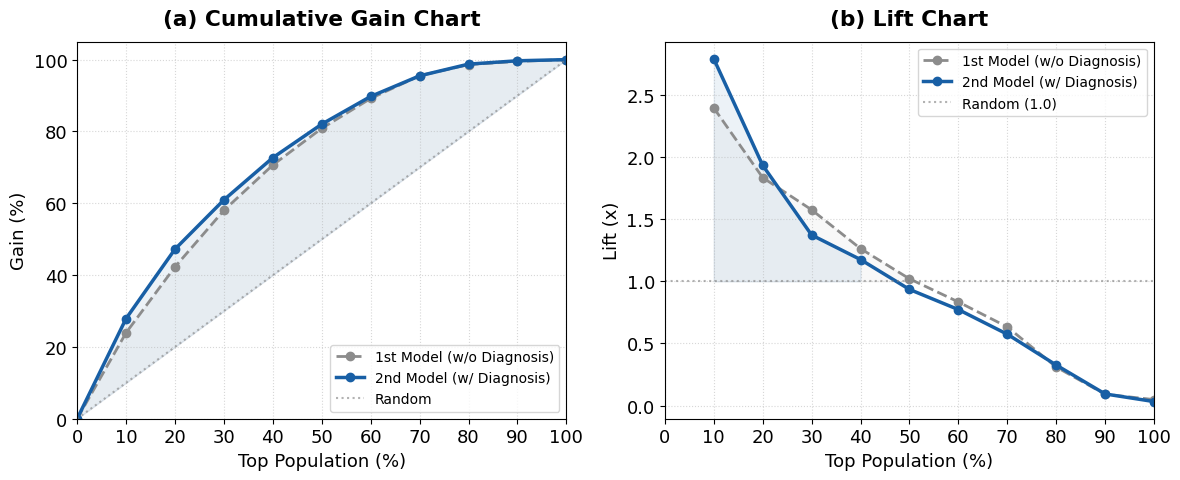


[1st Model (w/o Diagnosis)]
        total_count  positive_count        gain      lift
decile                                                   
10             1099             897   23.945542  2.394336
20             1099             687   42.285104  1.833789
30             1099             590   58.035238  1.574870
40             1099             473   70.662040  1.262565
50             1099             382   80.859584  1.019662
60             1098             312   89.188468  0.833571
70             1099             237   95.515216  0.632617
80             1099             116   98.611853  0.309635
90             1099              34   99.519487  0.090755
100            1099              18  100.000000  0.048047
Overall positive rate : 0.341
Top 10% Lift : 2.394x  |  Top 20% Lift : 1.834x

[2nd Model (w/ Diagnosis)]
        total_count  positive_count        gain      lift
decile                                                   
10             1099            1045   27.896423  2.78

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

# ── 공통 함수 ─────────────────────────────────────────────
def compute_gain_lift(y_true, y_pred, threshold=5.7):
    df = pd.DataFrame({'actual': y_true, 'pred': y_pred})
    df['is_positive'] = (df['actual'] >= threshold).astype(int)
    df = df.sort_values('pred', ascending=False).reset_index(drop=True)
    df['decile'] = pd.qcut(df.index, 10, labels=np.arange(10, 110, 10))

    summary = df.groupby('decile', observed=True)['is_positive'].agg(['count','sum'])
    summary.columns = ['total_count', 'positive_count']
    summary['cum_positive'] = summary['positive_count'].cumsum()
    summary['gain']         = summary['cum_positive'] / summary['positive_count'].sum() * 100
    overall_rate            = summary['positive_count'].sum() / summary['total_count'].sum()
    summary['precision']    = summary['positive_count'] / summary['total_count']
    summary['lift']         = summary['precision'] / overall_rate

    deciles = [0] + summary.index.astype(int).tolist()
    gains   = [0] + summary['gain'].tolist()
    lifts   = summary['lift'].tolist()
    lift_x  = summary.index.astype(int).tolist()
    return deciles, gains, lift_x, lifts, summary, overall_rate

# ── 두 모델 계산 ──────────────────────────────────────────
deciles_1, gains_1, lift_x_1, lifts_1, summary_1, rate_1 = compute_gain_lift(y_test, y_test_pred_refined)  # ← 1st
deciles_2, gains_2, lift_x_2, lifts_2, summary_2, rate_2 = compute_gain_lift(y_test, y_test_pred)          # ← 2nd

# ── 색상/스타일 설정 ──────────────────────────────────────
C1 = '#8c8c8c'   # 1st: 회색 (진단 미포함)
C2 = '#185FA5'   # 2nd: 파란색 (진단 포함)
Cr = 'gray'

plt.rcParams.update({'font.size': 13, 'font.family': 'sans-serif'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ── (a) Cumulative Gain Chart ─────────────────────────────
ax1.plot(deciles_1, gains_1, marker='o', color=C1, linewidth=2,
         linestyle='--', label='1st Model (w/o Diagnosis)')
ax1.plot(deciles_2, gains_2, marker='o', color=C2, linewidth=2.5,
         linestyle='-',  label='2nd Model (w/ Diagnosis)')
ax1.plot([0, 100], [0, 100], color=Cr, linestyle=':', linewidth=1.5,
         alpha=0.6, label='Random')

ax1.fill_between(deciles_1, deciles_1, gains_1, alpha=0.06, color=C1)
ax1.fill_between(deciles_2, deciles_2, gains_2, alpha=0.08, color=C2)

ax1.set_title('(a) Cumulative Gain Chart', fontweight='bold', pad=12)
ax1.set_xlabel('Top Population (%)')
ax1.set_ylabel('Gain (%)')
ax1.set_xlim(0, 100); ax1.set_ylim(0, 105)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.legend(loc='lower right', fontsize=10)

# ── (b) Lift Chart ────────────────────────────────────────
ax2.plot(lift_x_1, lifts_1, marker='o', color=C1, linewidth=2,
         linestyle='--', label='1st Model (w/o Diagnosis)')
ax2.plot(lift_x_2, lifts_2, marker='o', color=C2, linewidth=2.5,
         linestyle='-',  label='2nd Model (w/ Diagnosis)')
ax2.axhline(y=1, color=Cr, linestyle=':', linewidth=1.5, alpha=0.6,
            label='Random (1.0)')

ax2.fill_between(lift_x_1, 1, lifts_1,
                 where=[v >= 1 for v in lifts_1], alpha=0.06, color=C1)
ax2.fill_between(lift_x_2, 1, lifts_2,
                 where=[v >= 1 for v in lifts_2], alpha=0.08, color=C2)

ax2.set_title('(b) Lift Chart', fontweight='bold', pad=12)
ax2.set_xlabel('Top Population (%)')
ax2.set_ylabel('Lift (x)')
ax2.set_xlim(0, 100)
ax2.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig("gain_lift_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 수치 비교 출력 ─────────────────────────────────────────
for label, summary, lifts, rate in [
    ("1st Model (w/o Diagnosis)",  summary_1, lifts_1, rate_1),  # ← 변경
    ("2nd Model (w/ Diagnosis)", summary_2, lifts_2, rate_2),  # ← 변경
]:
    print(f"\n[{label}]")
    print(summary[['total_count', 'positive_count', 'gain', 'lift']].to_string())
    print(f"Overall positive rate : {rate:.3f}")
    print(f"Top 10% Lift : {lifts[0]:.3f}x  |  Top 20% Lift : {lifts[1]:.3f}x")

ROC 커브 비교

[1st Model] 5.7% 기준 ROC-AUC: 0.8196
[2nd Model] 5.7% 기준 ROC-AUC: 0.8438
[1st Model] 6.5% 기준 ROC-AUC: 0.8354
[2nd Model] 6.5% 기준 ROC-AUC: 0.9085


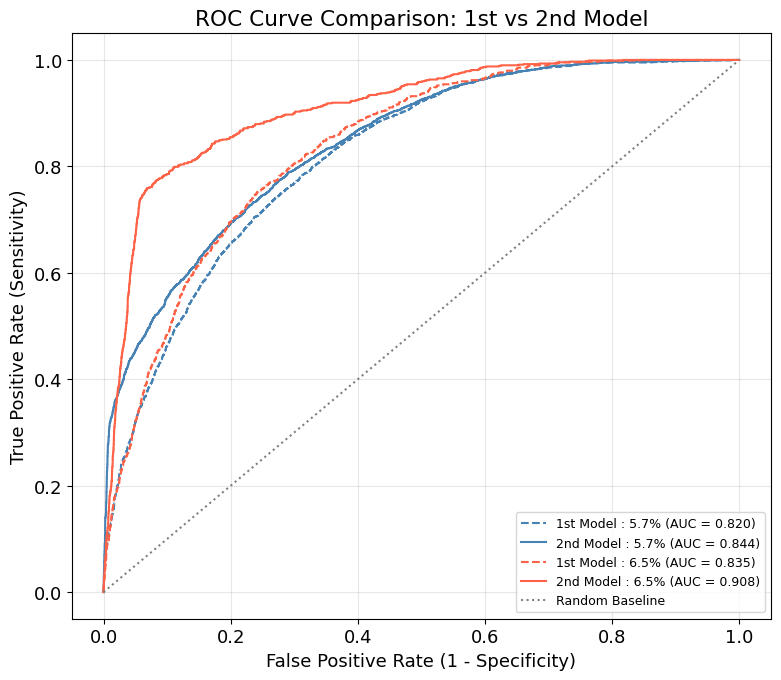

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ 두 모델의 예측값 준비
y_test_pred_1st = model_refined.predict(X_test_selected)  # 1차 모델 (진단 정보 제외)
y_test_pred_2nd = model.predict(X_test)                   # 2차 모델 (진단 정보 포함)

# 2️⃣ 설정 (기준점 및 스타일)
thresholds = [5.7, 6.5]
# 모델별 선 스타일 구분 (1차: 점선, 2차: 실선)
model_configs = [
    {'name': '1st Model', 'preds': y_test_pred_1st, 'ls': '--'},
    {'name': '2nd Model', 'preds': y_test_pred_2nd, 'ls': '-'}
]
colors = {5.7: 'steelblue', 6.5: 'tomato'}

# 3️⃣ 그래프 그리기
plt.figure(figsize=(8, 7))

for cutoff in thresholds:
    # 실제값 이진화 (기준점 기준)
    y_true_binary = (y_test >= cutoff).astype(int)

    for config in model_configs:
        fpr, tpr, _ = roc_curve(y_true_binary, config['preds'])
        auc_score = roc_auc_score(y_true_binary, config['preds'])

        label = f"{config['name']} : {cutoff}% (AUC = {auc_score:.3f})"
        plt.plot(fpr, tpr, color=colors[cutoff], linestyle=config['ls'], label=label)

        print(f"[{config['name']}] {cutoff}% 기준 ROC-AUC: {auc_score:.4f}")

# 그래프 디테일 설정
plt.plot([0, 1], [0, 1], linestyle=':', color='gray', label='Random Baseline')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve Comparison: 1st vs 2nd Model')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

오분류표 비교

In [41]:
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd

# 1️⃣ 설정
cutoff = 5.7


# 2️⃣ 데이터 준비
y_true_bin = (y_test.values > cutoff).astype(int)

# [1차 모델] 예측 및 이진화
y_pred_1st = model_refined.predict(X_test_selected)
y_pred_bin_1st = (y_pred_1st > cutoff).astype(int)

# [2차 모델] 예측 및 이진화
y_pred_2nd = model.predict(X_test)
y_pred_bin_2nd = (y_pred_2nd > cutoff).astype(int)

# 3️⃣ 리포트 생성 함수
def get_report_df(y_true, y_pred):
    report = classification_report(
        y_true, y_pred,
        target_names=target_names,
        output_dict=True
    )
    df = pd.DataFrame(report).transpose().round(3)
    return df

# 4️⃣ 결과 계산
report_1st = get_report_df(y_true_bin, y_pred_bin_1st)
report_2nd = get_report_df(y_true_bin, y_pred_bin_2nd)

# 5️⃣ 출력 (간격 및 구분선 추가)
print(f"\n" + "="*60)
print(f" [분류 성능 비교] Cutoff: {cutoff}%")
print("="*60)

print(f"\n▶ [1차 모델: 1st Refined]")
print("-" * 50)
print(report_1st)

print(f"\n\n" + " " * 50) # 가독성을 위한 큰 공백

print(f"▶ [2차 모델: 2nd Model]")
print("-" * 50)
print(report_2nd)
print("\n" + "="*60)


 [분류 성능 비교] Cutoff: 5.7%

▶ [1차 모델: 1st Refined]
--------------------------------------------------
               precision  recall  f1-score    support
Normal (<5.7)      0.876   0.757     0.812   7952.000
Risk (>=5.7)       0.530   0.718     0.610   3037.000
accuracy           0.746   0.746     0.746      0.746
macro avg          0.703   0.738     0.711  10989.000
weighted avg       0.780   0.746     0.756  10989.000


                                                  
▶ [2차 모델: 2nd Model]
--------------------------------------------------
               precision  recall  f1-score    support
Normal (<5.7)      0.889   0.774     0.827   7952.000
Risk (>=5.7)       0.557   0.747     0.639   3037.000
accuracy           0.766   0.766     0.766      0.766
macro avg          0.723   0.760     0.733  10989.000
weighted avg       0.797   0.766     0.775  10989.000



bootstrap_type='Bernoulli' + subsample=0.8의 효과:

과적합 감소 (각 트리가 다른 80% 샘플로 학습 → 트리 간 다양성 증가)
학습 속도 약간 향상 (샘플 수 감소)
일반화 성능 개선 가능성 (특히 데이터 노이즈가 많을 때)

단점:

학습 데이터가 적거나 신호가 약하면 오히려 성능 저하
결과 변동성 증가 (시드 고정으로 완화)

실행 시 클러스터 정보, 정확도 다소 변동 있음

In [32]:
# @title
# ============================================================
# 21. 오차 큰 샘플 분석 (K-Means 클러스터링) - 테스트 데이터 기준
# ============================================================
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("\n" + "="*60)
print("상대오차 > ±8% 샘플 K-Means 클러스터링 분석 (Test 기준)")
print("="*60)

# --- 오차 계산 (test 기준) ---
y_test_arr    = np.array(y_test)
test_pred_arr = np.array(y_test_pred)  # ← test_final_pred → y_test_pred

# 상대 오차 계산 (실제값 기준, 0인 샘플 제외)
relative_error = (test_pred_arr - y_test_arr) / np.where(y_test_arr == 0, np.nan, y_test_arr)

# 오차 ±8% 초과 필터링 (0인 샘플은 제외)
# 첫 번째 코드와 동일한 방식으로 통일
error_mask_np = ~((test_pred_arr >= y_test_arr * 0.92) & (test_pred_arr <= y_test_arr * 1.08))

print(f"\n전체 test 샘플 수: {len(y_test_arr)}")
print(f"상대오차 > ±8% 샘플 수: {error_mask_np.sum()} ({error_mask_np.mean()*100:.1f}%)")

# --- 클러스터링 피처 구성 ---
cluster_features = pd.DataFrame({
    'abs_error':    np.abs(relative_error)[error_mask_np],
    'actual':       y_test_arr[error_mask_np],
    'predicted':    test_pred_arr[error_mask_np],
    'error_signed': relative_error[error_mask_np],
})

# --- K-Means 클러스터링 ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_features['cluster'] = kmeans.fit_predict(X_scaled)

print("\n✅ K-Means 클러스터링 완료 (n_clusters=3)")

# --- 클러스터별 오차 통계 ---
print("\n📊 클러스터별 오차 통계:")
cluster_summary = cluster_features.groupby('cluster').agg(
    샘플수=('abs_error', 'count'),
    평균상대오차=('abs_error', 'mean'),
    최대상대오차=('abs_error', 'max'),
    평균실제값=('actual', 'mean'),
    평균예측값=('predicted', 'mean'),
    평균부호오차=('error_signed', 'mean'),
).round(4)
print(cluster_summary)

# --- 군집별 진단 비율 ---
error_idx = np.where(error_mask_np)[0]
cluster_features['DE1_dg'] = X_test['Diabetes Diagnosis'].iloc[error_idx].values

print("\n📊 클러스터별 당뇨 진단 비율 (DE1_dg):")
diag_summary = cluster_features.groupby('cluster')['DE1_dg'].value_counts().rename('개수').to_frame()
diag_summary['비율(%)'] = cluster_features.groupby('cluster')['DE1_dg'].value_counts(normalize=True).mul(100).round(2)
print(diag_summary)


상대오차 > ±8% 샘플 K-Means 클러스터링 분석 (Test 기준)

전체 test 샘플 수: 10989
상대오차 > ±8% 샘플 수: 2399 (21.8%)

✅ K-Means 클러스터링 완료 (n_clusters=3)

📊 클러스터별 오차 통계:
          샘플수  평균상대오차  최대상대오차   평균실제값   평균예측값  평균부호오차
cluster                                              
0         389  0.1431  0.3076  5.8051  6.6227  0.1431
1        1402  0.1098  0.2129  5.0721  5.6141  0.1075
2         608  0.1265  0.2962  6.7885  5.9195 -0.1265

📊 클러스터별 당뇨 진단 비율 (DE1_dg):
                  개수  비율(%)
cluster DE1_dg             
0       1.0      358  92.03
        0.0       31   7.97
1       0.0     1400  99.86
        1.0        2   0.14
2       0.0      441  72.53
        1.0      167  27.47


부트스트랩 검증

In [ ]:
# ============================================================
# 부트스트랩 교차검증 (2차 보정 모델)
# ============================================================
from sklearn.utils import resample
import numpy as np

n_bootstrap = 50  # 반복 횟수
bootstrap_results = []

print("부트스트랩 교차검증 시작...")
print("="*60)

for i in range(n_bootstrap):
    # 1. 부트스트랩 샘플링 (복원추출)
    X_boot, y_boot = resample(
        X_train_meta, y_train_residual,
        random_state=i
    )

    # OOB (Out-of-Bag) 샘플 추출
    oob_mask = ~X_train_meta.index.isin(X_boot.index)
    X_oob = X_train_meta[oob_mask]
    y_oob = y_train_residual[oob_mask]

    if len(X_oob) == 0:
        continue

    # 2. 2차 보정 모델 학습
    boot_model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=3,
        loss_function='RMSE',
        cat_features=['DE1_dg'],
        random_seed=i,
        verbose=0,
        task_type='CPU'
    )

    boot_model.fit(X_boot, y_boot)

    # 3. OOB 예측 (잔차 예측)
    oob_residual_pred = boot_model.predict(X_oob)

    # 4. 최종 예측 = 1차 예측 + 보정 잔차
    # OOB 인덱스에 해당하는 1차 예측값 가져오기
    oob_base_pred = train_base_pred[oob_mask]
    oob_final_pred = oob_base_pred + oob_residual_pred
    oob_true = y_train.values[oob_mask]

    # 5. 성능 평가
    mae = mean_absolute_error(oob_true, oob_final_pred)
    rmse = np.sqrt(mean_squared_error(oob_true, oob_final_pred))
    r2 = r2_score(oob_true, oob_final_pred)

    bootstrap_results.append({'mae': mae, 'rmse': rmse, 'r2': r2})

    if (i+1) % 10 == 0:
        print(f"  [{i+1}/{n_bootstrap}] 완료")

# ============================================================
# 결과 요약
# ============================================================
results_df = pd.DataFrame(bootstrap_results)

print("\n" + "="*60)
print("부트스트랩 교차검증 결과 (OOB 기준)")
print("="*60)
print(f"MAE  : {results_df['mae'].mean():.4f} ± {results_df['mae'].std():.4f}")
print(f"RMSE : {results_df['rmse'].mean():.4f} ± {results_df['rmse'].std():.4f}")
print(f"R²   : {results_df['r2'].mean():.4f} ± {results_df['r2'].std():.4f}")
print(f"\n95% 신뢰구간")
print(f"MAE  : [{results_df['mae'].quantile(0.025):.4f}, {results_df['mae'].quantile(0.975):.4f}]")
print(f"RMSE : [{results_df['rmse'].quantile(0.025):.4f}, {results_df['rmse'].quantile(0.975):.4f}]")
print(f"R²   : [{results_df['r2'].quantile(0.025):.4f}, {results_df['r2'].quantile(0.975):.4f}]")

부트스트랩 교차검증 시작...
  [10/50] 완료
  [20/50] 완료
  [30/50] 완료
  [40/50] 완료
  [50/50] 완료

부트스트랩 교차검증 결과 (OOB 기준)
MAE  : 0.2892 ± 0.0015
RMSE : 0.3938 ± 0.0025
R²   : 0.5021 ± 0.0055

95% 신뢰구간
MAE  : [0.2859, 0.2913]
RMSE : [0.3884, 0.3977]
R²   : [0.4919, 0.5121]
